# Jagran Lakecity University
## Faculty of Science and Technology
### BTech CSE

---

## Practical Record: Assignment 2 - Module 2
### **Practical 3: Implementation and Visualization of Activation Functions (Sigmoid, Tanh, ReLU)**

| Academic Details | Information |
| :--- | :--- |
| **Course** | Soft Computing |
| **Module** | Module II: Fuzzy Logic and Systems |
| **Student Name** | *Aakash Sarang* |
| **Enrollment No.** | *2023BTCSE001* |
| **Academic Session** | 2026 – 2027 |

---

### 1. Aim
To implement and visualize Sigmoid, Tanh, and ReLU activation functions using Python.

### 2. Theory: Why Do We Need Activation Functions?

Without activation functions, stacking layers of neurons would still only draw straight lines. Activation functions add **curves (non-linearity)** so networks can learn complex patterns like photos, voices, and medical data.

#### 1. Sigmoid Function
- **Formula:** $\sigma(z) = \frac{1}{1 + e^{-z}}$
- **Output Range:** Always between $0$ and $1$.
- **Best Use:** At the final output layer to predict a probability (like 80% chance of rain).
- **Slope Formula (Derivative):** $\sigma'(z) = \sigma(z)(1 - \sigma(z))$

#### 2. Tanh Function
- **Formula:** $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$
- **Output Range:** Between $-1$ and $+1$ (centered around zero).
- **Best Use:** Hidden layers when negative numbers are helpful.
- **Slope Formula (Derivative):** $\tanh'(z) = 1 - \tanh^2(z)$

#### 3. ReLU Function (Most Popular)
- **Formula:** $\text{ReLU}(z) = \max(0, z)$
- **Output Range:** From $0$ to as high as the input goes.
- **Best Use:** Hidden layers of almost all modern deep learning models.
- **Slope Formula (Derivative):** $1$ if $z > 0$, else $0$. It is super simple and fast for computers to compute.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Numerically stable Sigmoid function
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

# Sigmoid derivative: sigma'(z) = sigma(z) * (1 - sigma(z))
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1.0 - s)

# Hyperbolic tangent function
def tanh_func(z):
    return np.tanh(z)

# Tanh derivative: tanh'(z) = 1 - tanh^2(z)
def tanh_derivative(z):
    return 1.0 - np.tanh(z)**2

# Rectified Linear Unit: max(0, z)
def relu(z):
    return np.maximum(0.0, z)

# ReLU derivative: 1 if z > 0 else 0
def relu_derivative(z):
    return np.where(z > 0.0, 1.0, 0.0)

# Leaky ReLU: z if z > 0 else alpha * z
def leaky_relu(z, alpha=0.1):
    return np.where(z > 0.0, z, alpha * z)

# Leaky ReLU derivative: 1 if z > 0 else alpha
def leaky_relu_derivative(z, alpha=0.1):
    return np.where(z > 0.0, 1.0, alpha)

print("All activation functions and their analytical derivatives defined successfully.")

All activation functions and their analytical derivatives defined successfully.


### 3. Testing the Functions with Sample Numbers

#### What this cell does:
In this code cell, we define Python functions for Sigmoid, Tanh, and ReLU and their derivatives using NumPy. Then we pass sample test points $[-5.0, -2.0, -0.5, 0.0, 0.5, 2.0, 5.0]$ through each formula to print their exact values and slopes.

In [2]:
eval_points = np.array([-5.0, -2.0, -0.5, 0.0, 0.5, 2.0, 5.0])

print("=" * 80)
print(f"{'Input (z)':<10} | {'Sigmoid':<14} | {'Tanh':<14} | {'ReLU':<12} | {'LeakyReLU (a=0.1)':<16}")
print("=" * 80)
for z in eval_points:
    print(f"{z:<10.1f} | {sigmoid(z):<14.4f} | {tanh_func(z):<14.4f} | {relu(z):<12.4f} | {leaky_relu(z):<16.4f}")
print("=" * 80)

print("\n" + "=" * 80)
print(f"{'Input (z)':<10} | {'Sigmoid Deriv':<14} | {'Tanh Deriv':<14} | {'ReLU Deriv':<12} | {'Leaky Deriv':<16}")
print("=" * 80)
for z in eval_points:
    print(f"{z:<10.1f} | {sigmoid_derivative(z):<14.4f} | {tanh_derivative(z):<14.4f} | {relu_derivative(z):<12.4f} | {leaky_relu_derivative(z):<16.4f}")
print("=" * 80)

Input (z)  | Sigmoid        | Tanh           | ReLU         | LeakyReLU (a=0.1)
-5.0       | 0.0067         | -0.9999        | 0.0000       | -0.5000         
-2.0       | 0.1192         | -0.9640        | 0.0000       | -0.2000         
-0.5       | 0.3775         | -0.4621        | 0.0000       | -0.0500         
0.0        | 0.5000         | 0.0000         | 0.0000       | 0.0000          
0.5        | 0.6225         | 0.4621         | 0.5000       | 0.5000          
2.0        | 0.8808         | 0.9640         | 2.0000       | 2.0000          
5.0        | 0.9933         | 0.9999         | 5.0000       | 5.0000          

Input (z)  | Sigmoid Deriv  | Tanh Deriv     | ReLU Deriv   | Leaky Deriv     
-5.0       | 0.0066         | 0.0002         | 0.0000       | 0.1000          
-2.0       | 0.1050         | 0.0707         | 0.0000       | 0.1000          
-0.5       | 0.2350         | 0.7864         | 0.0000       | 0.1000          
0.0        | 0.2500         | 1.0000         | 0.0

### 4. Plotting Graphs of Each Function and Its Slope

#### What this cell does:
In this code cell, we generate 600 points between $-6.0$ and $+6.0$ and plot:
- **Top Row:** The curves of Sigmoid, Tanh, and ReLU.
- **Bottom Row:** The slope (derivative) curves showing how fast each function changes.

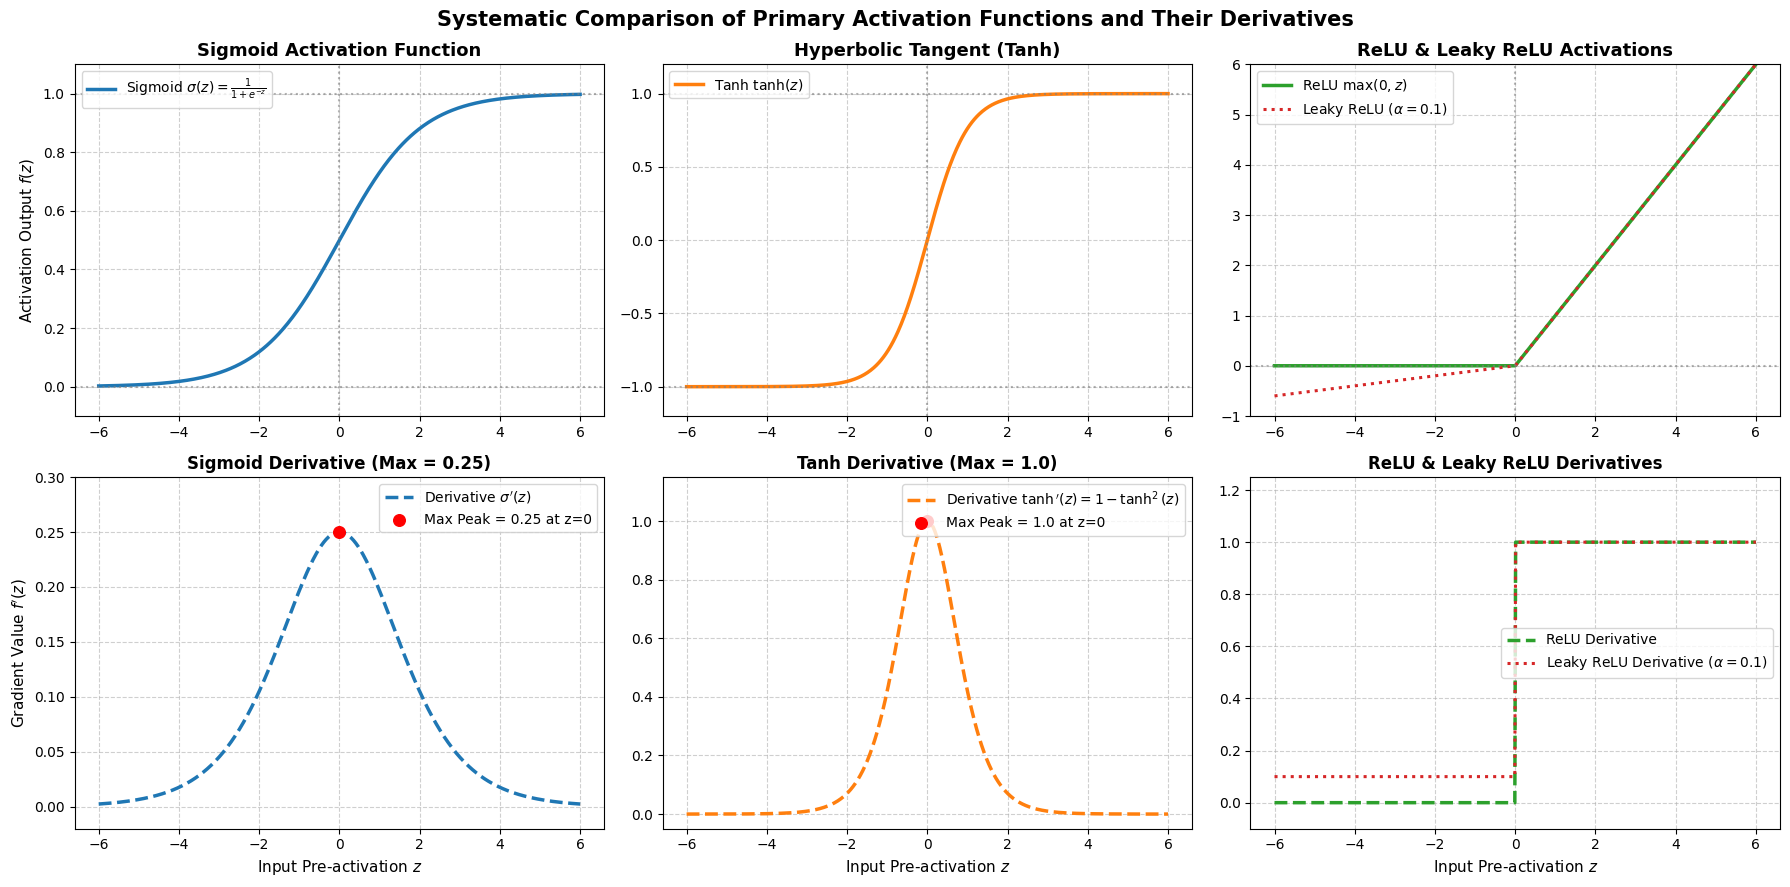

In [3]:
z = np.linspace(-6.0, 6.0, 600)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# 1. Sigmoid Function & Gradient
axes[0, 0].plot(z, sigmoid(z), color='#1f77b4', linewidth=2.5, label=r'Sigmoid $\sigma(z) = \frac{1}{1+e^{-z}}$')
axes[0, 0].axhline(0, color='gray', linestyle=':', alpha=0.6)
axes[0, 0].axhline(1, color='gray', linestyle=':', alpha=0.6)
axes[0, 0].axvline(0, color='gray', linestyle=':', alpha=0.6)
axes[0, 0].set_title("Sigmoid Activation Function", fontsize=13, weight='bold')
axes[0, 0].set_ylabel("Activation Output $f(z)$", fontsize=11)
axes[0, 0].set_ylim(-0.1, 1.1)
axes[0, 0].grid(True, linestyle='--', alpha=0.6)
axes[0, 0].legend(loc="upper left", fontsize=10)

axes[1, 0].plot(z, sigmoid_derivative(z), color='#1f77b4', linestyle='--', linewidth=2.5, 
                label=r"Derivative $\sigma'(z)$")
axes[1, 0].scatter([0], [0.25], color='red', s=70, zorder=5, label='Max Peak = 0.25 at z=0')
axes[1, 0].set_title("Sigmoid Derivative (Max = 0.25)", fontsize=12, weight='bold')
axes[1, 0].set_xlabel("Input Pre-activation $z$", fontsize=11)
axes[1, 0].set_ylabel("Gradient Value $f'(z)$", fontsize=11)
axes[1, 0].set_ylim(-0.02, 0.30)
axes[1, 0].grid(True, linestyle='--', alpha=0.6)
axes[1, 0].legend(loc="upper right", fontsize=10)

# 2. Tanh Function & Gradient
axes[0, 1].plot(z, tanh_func(z), color='#ff7f0e', linewidth=2.5, label=r'Tanh $\tanh(z)$')
axes[0, 1].axhline(-1, color='gray', linestyle=':', alpha=0.6)
axes[0, 1].axhline(1, color='gray', linestyle=':', alpha=0.6)
axes[0, 1].axvline(0, color='gray', linestyle=':', alpha=0.6)
axes[0, 1].set_title("Hyperbolic Tangent (Tanh)", fontsize=13, weight='bold')
axes[0, 1].set_ylim(-1.2, 1.2)
axes[0, 1].grid(True, linestyle='--', alpha=0.6)
axes[0, 1].legend(loc="upper left", fontsize=10)

axes[1, 1].plot(z, tanh_derivative(z), color='#ff7f0e', linestyle='--', linewidth=2.5, 
                label=r"Derivative $\tanh'(z) = 1 - \tanh^2(z)$")
axes[1, 1].scatter([0], [1.0], color='red', s=70, zorder=5, label='Max Peak = 1.0 at z=0')
axes[1, 1].set_title("Tanh Derivative (Max = 1.0)", fontsize=12, weight='bold')
axes[1, 1].set_xlabel("Input Pre-activation $z$", fontsize=11)
axes[1, 1].set_ylim(-0.05, 1.15)
axes[1, 1].grid(True, linestyle='--', alpha=0.6)
axes[1, 1].legend(loc="upper right", fontsize=10)

# 3. ReLU & Leaky ReLU Functions & Gradients
axes[0, 2].plot(z, relu(z), color='#2ca02c', linewidth=2.5, label=r'ReLU $\max(0, z)$')
axes[0, 2].plot(z, leaky_relu(z, alpha=0.1), color='#d62728', linestyle=':', linewidth=2.2, 
                label=r'Leaky ReLU ($\alpha=0.1$)')
axes[0, 2].axhline(0, color='gray', linestyle=':', alpha=0.6)
axes[0, 2].axvline(0, color='gray', linestyle=':', alpha=0.6)
axes[0, 2].set_title("ReLU & Leaky ReLU Activations", fontsize=13, weight='bold')
axes[0, 2].set_ylim(-1.0, 6.0)
axes[0, 2].grid(True, linestyle='--', alpha=0.6)
axes[0, 2].legend(loc="upper left", fontsize=10)

axes[1, 2].plot(z, relu_derivative(z), color='#2ca02c', linestyle='--', linewidth=2.5, label='ReLU Derivative')
axes[1, 2].plot(z, leaky_relu_derivative(z, alpha=0.1), color='#d62728', linestyle=':', linewidth=2.2, 
                label=r'Leaky ReLU Derivative ($\alpha=0.1$)')
axes[1, 2].set_title("ReLU & Leaky ReLU Derivatives", fontsize=12, weight='bold')
axes[1, 2].set_xlabel("Input Pre-activation $z$", fontsize=11)
axes[1, 2].set_ylim(-0.1, 1.25)
axes[1, 2].grid(True, linestyle='--', alpha=0.6)
axes[1, 2].legend(loc="center right", fontsize=10)

plt.suptitle("Systematic Comparison of Primary Activation Functions and Their Derivatives", 
             fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 5. Results and What We Observed

| Function | Output Range | Is it Centered at Zero? | Maximum Slope | Best Place to Use It |
| :--- | :--- | :--- | :--- | :--- |
| **Sigmoid** | Between 0 and 1 | No (centered at 0.5) | 0.25 | Output layer for Yes/No predictions |
| **Tanh** | Between -1 and +1 | Yes | 1.00 | Hidden layers in older networks |
| **ReLU** | 0 and positive numbers | No | 1.00 (for all positive inputs) | Hidden layers in modern networks |

#### Key Takeaways in Simple Words:
1. **The 'Flattening Slope' Problem (Vanishing Gradient):**
   - For very big positive or negative numbers, the curve of Sigmoid and Tanh becomes almost flat.
   - When a curve is flat, its slope is near zero. In deep networks, this makes learning grind to a halt because the error signal shrinks away.
2. **Why ReLU is Everyone's Favorite:**
   - For positive numbers, ReLU never flattens out—its slope stays at a solid 1.0. This lets error signals flow backward easily through many layers.
   - It is also very easy for computers: just check `if x > 0`.
3. **One Thing to Watch with ReLU:**
   - If an input is negative, ReLU gives 0 with a slope of 0. If a neuron stays negative all the time, it never updates (called a 'dead neuron').

---
### 6. Conclusion
1. We successfully wrote and tested Sigmoid, Tanh, and ReLU functions in Python.
2. We plotted each function alongside its slope to see how it responds to different numbers.
3. We learned that ReLU is best for hidden layers, while Sigmoid is best for output probabilities.